# Dependency imports

In [1]:
import torch

#Vajon melyik lesz?
from timm import create_model
from torchvision.models import swin_b   #<- Eddig 2 hajszállal

from Training.library import validate
from Training.training import Config, TrainingResources, initMelanomaDetectorTrainers, trainingLoop
import Training.metrics as m
import Training.plotting as plots

/home/csuti/Development/Medical_Data_Processing/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# MelanomaDetector specific configuration

In [ ]:
c = Config("MelanomaDetector")

#Configure execution to needs
c.purge    = False

c.loadBest = False

#CoAtNetnél alapból 8e-7
#Itt finomhangolás megy, tehát kisebb is elég
c.learningRate = 8e-7
c.weightDecay  = 1e-8

c.numClasses = 1  #Melanoma valószínüsége
c.batchSize = 8
c.workers = 8


# Initialize resources

In [3]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
oldClasses = 8

Using cuda device


### Merge the followings once model is decided

In [5]:
#__Ha Swin__
model = swin_b(weights=None)
model.head = torch.nn.Linear(model.head.in_features, oldClasses) #oldClasses so base is loadable
#The starting base is the test model already trained on skin lesions
model.load_state_dict(
    torch.load("Models/Swin-B/best_val.pth", map_location=torch.device(device))
)
model.head = torch.nn.Linear(model.head.in_features, c.numClasses)

In [ ]:
#__Ha CoAtNet__
#The winner architecture is CoAtNet-2
model = create_model(
    "coatnet_2_rw_224",
    pretrained=False,       #I'll load weights anyway
    num_classes=oldClasses  #So the base is loadable
)
#The starting base is the test model already trained on skin lesions
model.load_state_dict(
    torch.load("Models/CoAtNet-2/best_val.pth", map_location=torch.device(device))
)
#The classifier is binary from now
model.reset_classifier(2)

In [6]:
#Freeze every layer exept the classifier
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True


TR = TrainingResources(c, model, initMelanomaDetectorTrainers, device)
TR.load(c)

print(TR.criterion)
print(TR.optimizer)

#Note: After this point only some config changes will apply

BCEWithLogitsLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 8e-07
    maximize: False
    weight_decay: 1e-08
)


# Execute training

In [ ]:
# Override training related config if neccesary
c.training = True
c.gpuSleep = 180
c.trainingEpochs = 5

trainingLoop(c, TR, stopAt=0)

display(TR.history)

Epoch 1/30 	| 

KeyboardInterrupt: 

# Plots of learning process

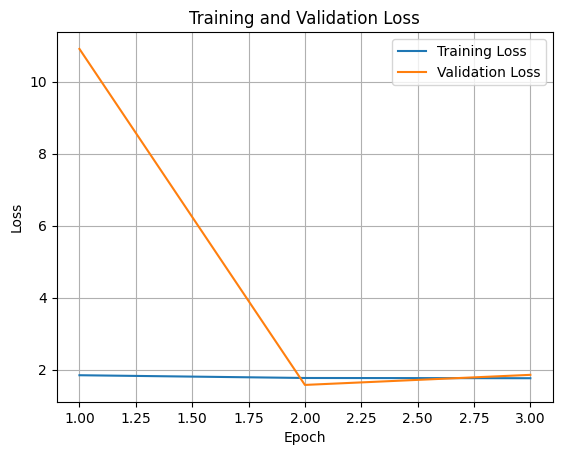

<Figure size 640x480 with 0 Axes>

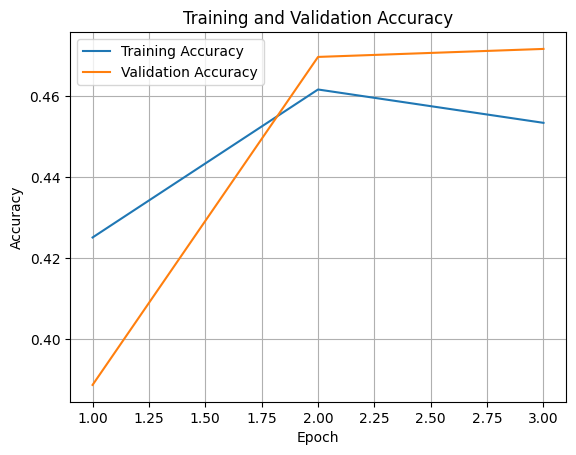

<Figure size 640x480 with 0 Axes>

In [ ]:
plots.plotTraining(TR.history, TR.plotsFolder)

# Metrics of best model on test data

### Evaluate on test set

In [ ]:
#Reload weights with best validation
c.loadBest = True

TR.load(c)

#Evaluate on test set
test_loss, test_acc, CM = validate(TR.model, TR.test_loader, TR.criterion, device)

print(f"Test loss: {test_loss} \t | Test acc: {test_acc}")

Loaded state
Test loss: 1.8766146159782184 	 | Test acc: 0.4582677165354331


### Plots of test results

Models/ResNet-152/plots


,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,7,8,2,0,7,7,2,0
Basal cell carcinoma,45,188,118,14,267,117,44,8
Benign keratosis-like lesions,0,2,0,0,4,0,0,0
Dermatofibroma,0,0,0,0,0,0,0,0
Melanocytic nevi,6,35,71,6,782,142,7,10
Melanoma,30,100,72,5,228,187,11,8
Squamous cell carcinoma,0,0,0,0,0,0,0,0
Vascular lesions,0,0,0,0,0,0,0,0


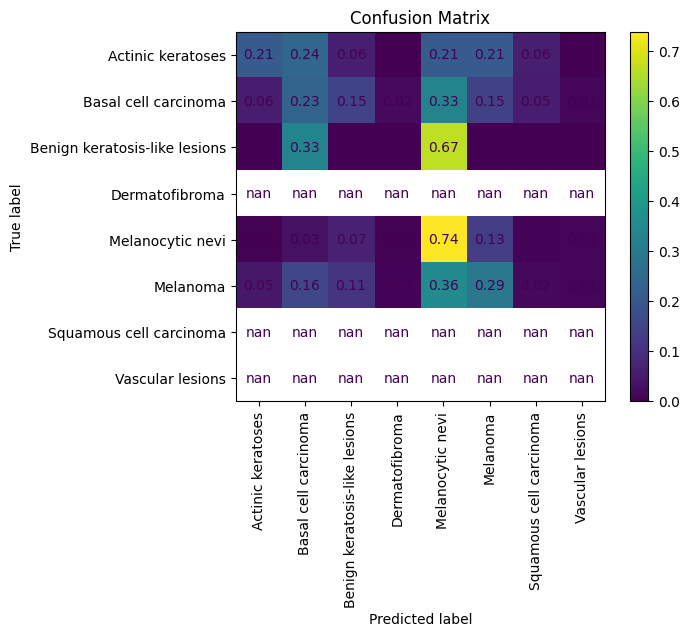

,accuracy,precision,recall,f1
Actinic keratoses,95.7874,21.2121,7.9545,11.5702
Basal cell carcinoma,70.1575,23.4707,56.4565,33.1570
Benign keratosis-like lesions,89.4094,0.0000,0.0000,0.0000
Dermatofibroma,99.0157,0.0000,0.0000,0.0000
Melanocytic nevi,69.1732,73.8432,60.7143,66.6383
Melanoma,71.6535,29.1732,41.2804,34.1865
Squamous cell carcinoma,97.4803,0.0000,0.0000,0.0000
Vascular lesions,98.9764,0.0000,0.0000,0.0000


<Figure size 640x480 with 0 Axes>

In [ ]:
print(TR.plotsFolder)

display(CM)
plots.plotConfusionMatrix(CM, TR.plotsFolder)

metrics = plots.deriveMetrics(CM, TR.plotsFolder)
display(metrics)

### Inspection using captum